# Assignment 3

Question: What are Retention Trends among Different Generations?

I want to determine which variables influence people's choice to continue to go a grocery store and ultimately what to focus on.

The chosen predictor variable will be PS3 - 'I will continue purchasing from this grocery store even if competitors offer reasonable price'

### The Variables 

In [2]:

import pandas as pd
import numpy as np
import skimpy
import requests
from io import BytesIO
from great_tables import GT,html
import plotnine as p9
import gspread
import csv

In [3]:
empathy = pd.DataFrame({
    'E1' : 'The employees of the grocery store understand the specific needs of their customers',
    'E2' : 'The grocery store understands what I need and strives to accommodate me',
    'E3' : 'The grocery store has employees who give customers personal service',
    'E4' : 'The employees of the grocery stores are very efficient'
},index=[1])
convenience = pd.DataFrame({
    'C1' : 'The grocery store layout makes it easy for me to find what I need',
    'C2' : 'The grocery store layout makes it easy for me to move around',
    'C3' : '	The grocery store always has merchandise available'
},index=[1])
PriceSensitivity = pd.DataFrame({
    'PS1' : 'I will continue to buy from the grocery store even if prices increase',
    'PS2' : 'I am willing to pay a higher price for the benefit of having the grocery store located close to me',
    'PS3' : 'I am willing to stick with the grocery store and not travel to other competitors outside the township who might offer reasonable prices'
},index=[1])
PhysEnv = pd.DataFrame({
    'PE1' :	'The store overall has an appealing looking appearance',
    'PE2' :	'The grocery store provides a clean shopping environment',
    'PE3' :	'The grocery store has wide and open aisles',
    'PE4' :	'The grocery store has well-marked aisle signage',
    'PE5' :	'The grocery store provides a pleasant shopping environment',
    'PE6' :	"The grocery store's environment feels safe and secure"
},index=[1])
Perceived_Prod_Quality = pd.DataFrame({
    'PPQ1' : 'The overall quality of products I buy from the grocery store is good',
    'PPQ2' : 'The quality of the produce department in the grocery store is good',
    'PPQ3' : 'The quality of the meat department in the grocery store is good',
    'PPQ4' : 'The quality of in-store bakery is good'
},index=[1])
Customer_Trust = pd.DataFrame({
    'CT1' :	'The grocery store always meets my expectations',	
    'CT2' : 'I can count on the store to meet my grocery needs',
    'CT3' :	'The grocery store is reliable',
    'CT4' :	'The grocery store can always be trusted',
    'CT5' :	'The grocery store consistently provides good quality products and services',
    'CT6' :	"The grocery store's offerings are worth the money I spend"
},index=[1])
Perceived_Value = pd.DataFrame({
    'PV1' :	'The grocery store products have a good value for money',
    'PV2' :	'The grocery store products are affordable',
    'PV3' :	'In this grocery store, compared to other stores outside the township, I can save money'
},index=[1])
Purchase_Intention = pd.DataFrame({
    'PI1' :	'I intend to purchase from this grocery store',
    'PI2' :	'I would like to repeat my experience in this kind of grocery store',
    'PI3' :	'I would purchase from this grocery store in the future',
    'PI4' :	'I would recommend purchasing in this grocery store to others'
},index=[1])

Gender = pd.DataFrame({
    'Variable' : ['Gender']*3,
    'Category': ['Male','Female','Prefer Not to Say'],
    'Encoding' : [1,2,3],
    'Frequency': [133,134,14]
})
Age = pd.DataFrame({
    'Variable' : ['Age']*5,
    'Category': ['18-22','23-28','29-35','35-49','50-65'],
    'Encoding': [1,2,3,4,5],
    'Frequency': [64,68,47,54,48]
})
MaritalStatus = pd.DataFrame({
    'Variable' : ['Marital Status']*2,
    'Category':['Single','Married'],
    'Encoding' : [1,2],
    'Frequency' : [1,2]
})
Education = pd.DataFrame({
    'Variable' : ['Education Level']*5,
    'Category' : ['No Formal Education','Basic Education','Diploma','Degree','Postgraduate Degree'],
    'Encoding' : [1,2,3,4,5],
    'Frequency' : [34,128,69,47,3]
})
Regular_Customer = pd.DataFrame({
    'Variable' : ['Regular Customer']*2,
    'Category' : ['Regular','Need-Based'],
    'Encoding' : [1,2],
    'Frequency' : [232,49]
})
Shopping_Frequency = pd.DataFrame({
    'Variable' : ['Shopping Frequency']*5,
    'Category' : ['1-2 Times per Week','2-3 Times per Week','3-4 Times per Week','5-6 Times per Week','6-7 Times per Week'],
    'Encoding' : [1,2,3,4,5],
    'Frequency' : [112,75,46,26,22]
})
EmploymentStatus = pd.DataFrame({
    'Variable' : ['Employment Status']*2,
    'Category' : ['Employed','Unemployed'],
    'Encoding' : [1,2],
    'Frequency' : [147,134]
})

dfs2 = [Gender,Age,MaritalStatus,EmploymentStatus,Education,Regular_Customer,Shopping_Frequency]
Personal_Data = pd.DataFrame()
Personal_Data = pd.concat(dfs2)
(
    GT(Personal_Data)
    .tab_header(title='Data Dictionary of Personal Information')
).save('PersonalInfo dict.png')

GT(_tbl_data=             Variable             Category  Encoding  Frequency
0              Gender                 Male         1        133
1              Gender               Female         2        134
2              Gender    Prefer Not to Say         3         14
0                 Age                18-22         1         64
1                 Age                23-28         2         68
2                 Age                29-35         3         47
3                 Age                35-49         4         54
4                 Age                50-65         5         48
0      Marital Status               Single         1          1
1      Marital Status              Married         2          2
0   Employment Status             Employed         1        147
1   Employment Status           Unemployed         2        134
0     Education Level  No Formal Education         1         34
1     Education Level      Basic Education         2        128
2     Education Level              Diploma         3         69
3     Education Level               Degree         4         47
4     Education Level  Postgraduate Degree         5          3
0    Regular Customer              Regular         1        232
1    Regular Customer           Need-Based         2         49
0  Shopping Frequency   1-2 Times per Week         1        112
1  Shopping Frequency   2-3 Times per Week         2         75
2  Shopping Frequency   3-4 Times per Week         3         46
3  Shopping Frequency   5-6 Times per Week         4         26
4  Shopping Frequency   6-7 Times per Week         5         22, _body=<great_tables._gt_data.Body object at 0x000002B9BA2033D0>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='Category', type=<ColInfoTypeEnum.default: 1>, column_label='Category', column_align='left', column_width=None), ColInfo(var='Encoding', type=<ColInfoTypeEnum.default: 1>, column_label='Encoding', column_align='right', column_width=None), ColInfo(var='Frequency', type=<ColInfoTypeEnum.default: 1>, column_label='Frequency', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002B9B88F8F90>, _spanners=Spanners([]), _heading=Heading(title='Data Dictionary of Personal Information', subtitle=None, preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002B9BBDB4DD0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category=

In [4]:

dfs = [empathy, convenience, PriceSensitivity, PhysEnv, Perceived_Prod_Quality, Customer_Trust, Perceived_Value, Purchase_Intention]
Social_Data = pd.DataFrame(columns=['Variable', 'Description'])

for df in dfs:
    temp = df.T.reset_index()
    temp.columns = ['Variable', 'Description']
    Social_Data = pd.concat([Social_Data, temp], ignore_index=True)

(
    GT(Social_Data)
    .tab_header(
        title='Data Dictionary of Encoded Variables',
        subtitle='All these Variables are either on a 5 Lickert Scale from 1(Strongly Disagree) to 5(Strongly Agree)'
    )
    
)

GT(_tbl_data=   Variable                                        Description
0        E1  The employees of the grocery store understand ...
1        E2  The grocery store understands what I need and ...
2        E3  The grocery store has employees who give custo...
3        E4  The employees of the grocery stores are very e...
4        C1  The grocery store layout makes it easy for me ...
5        C2  The grocery store layout makes it easy for me ...
6        C3  \tThe grocery store always has merchandise ava...
7       PS1  I will continue to buy from the grocery store ...
8       PS2  I am willing to pay a higher price for the ben...
9       PS3  I am willing to stick with the grocery store a...
10      PE1  The store overall has an appealing looking app...
11      PE2  The grocery store provides a clean shopping en...
12      PE3         The grocery store has wide and open aisles
13      PE4    The grocery store has well-marked aisle signage
14      PE5  The grocery store provides a pleasant shopping...
15      PE6  The grocery store's environment feels safe and...
16     PPQ1  The overall quality of products I buy from the...
17     PPQ2  The quality of the produce department in the g...
18     PPQ3  The quality of the meat department in the groc...
19     PPQ4             The quality of in-store bakery is good
20      CT1     The grocery store always meets my expectations
21      CT2  I can count on the store to meet my grocery needs
22      CT3                      The grocery store is reliable
23      CT4            The grocery store can always be trusted
24      CT5  The grocery store consistently provides good q...
25      CT6  The grocery store's offerings are worth the mo...
26      PV1  The grocery store products have a good value f...
27      PV2          The grocery store products are affordable
28      PV3  In this grocery store, compared to other store...
29      PI1       I intend to purchase from this grocery store
30      PI2  I would like to repeat my experience in this k...
31      PI3  I would purchase from this grocery store in th...
32      PI4  I would recommend purchasing in this grocery s..., _body=<great_tables._gt_data.Body object at 0x000002B9BBD43910>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='Description', type=<ColInfoTypeEnum.default: 1>, column_label='Description', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002B9BBD8A690>, _spanners=Spanners([]), _heading=Heading(title='Data Dictionary of Encoded Variables', subtitle='All these Variables are either on a 5 Lickert Scale from 1(Strongly Disagree) to 5(Strongly Agree)', preheader=None), _stubhead=None, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002B9BBD95210>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=T

In [5]:
%pip install pandas
%pip install numpy
%pip install skimpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\alexa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\alexa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: C:\Users\alexa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Loading and Preparing Data

In [6]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSBBxryD5-kWzRiwe7Vbeq8jfijaVYmswfyM7EBPJFAQd9jFx3qD9mfoQQ2Sk3WqTCkbvNnNaspFIdC/pub?gid=866868886&single=true&output=csv'

req = requests.get(url)

df = pd.read_csv(BytesIO(req.content))

# Aggregating the Dataset

In [7]:
skimpy.skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 281    │ │ int64       │ 41    │                                                          │
│ │ Number of columns │ 41     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column                   ┃ NA  ┃ NA %   ┃ mean    ┃ sd       ┃ p0  ┃ p25   ┃ p50  ┃ p75  ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ Gender                   │   0 │      0 │   1.577 │   0.5874 │   1 │     1 │    2 │    2 │     3 │ ▇  ▇ ▁  │  │
│ │ Age                      │   0 │      0 │   2.836 │    1.417 │   1 │     2 │    3 │    4 │     5 │ ▇▇ ▆▆▆  │  │
│ │ Marital Status           │   0 │      0 │   1.552 │   0.7209 │   1 │     1 │    1 │    2 │     3 │ ▇  ▃ ▂  │  │
│ │ Employment Status        │   0 │      0 │   1.477 │   0.5004 │   1 │     1 │    1 │    2 │     2 │ ▇    ▇  │  │
│ │ Level of Education       │   0 │      0 │   2.491 │   0.9453 │   1 │     2 │    2 │    3 │     5 │  ▂▇ ▅▃  │  │
│ │ Regular Customer         │   0 │      0 │   1.174 │   0.3801 │   1 │     1 │    1 │    1 │     2 │ ▇    ▂  │  │
│ │ Shopping frequency       │   0 │      0 │   2.185 │    1.268 │   1 │     1 │    2 │    3 │     5 │ ▇▅ ▃▂▂  │  │
│ │ E1                       │   0 │      0 │   3.491 │    1.159 │   1 │     3 │    4 │    4 │     5 │ ▂▃ ▆▇▅  │  │
│ │ E2                       │   0 │      0 │   3.698 │    1.041 │   1 │     3 │    4 │    4 │     5 │ ▁▁ ▅▇▃  │  │
│ │ E3                       │   0 │      0 │   3.192 │    1.092 │   1 │     3 │    3 │    4 │     5 │ ▂▃ ▇▆▂  │  │
│ │ E4                       │   0 │      0 │   3.498 │    1.042 │   1 │     3 │    4 │    4 │     5 │ ▁▃ ▆▇▃  │  │
│ │ C1                       │   0 │      0 │   3.683 │    1.249 │   1 │     3 │    4 │    5 │     5 │ ▂▂ ▂▇▆  │  │
│ │ C2                       │   0 │      0 │   3.769 │    1.124 │   1 │     3 │    4 │    5 │     5 │ ▁▁ ▅▇▆  │  │
│ │ C3                       │   0 │      0 │   3.822 │    1.117 │   1 │     3 │    4 │    5 │     5 │ ▁▂ ▅▆▇  │  │
│ │ PS1                      │   0 │      0 │   2.883 │     1.33 │   1 │     2 │    3 │    4 │     5 │ ▇▅ ▇▇▃  │  │
│ │ PS2                      │   0 │      0 │   3.043 │    1.236 │   1 │     2 │    3 │    4 │     5 │ ▅▆ ▇▇▃  │  │
│ │ PS3                      │   0 │      0 │   3.117 │    1.281 │   1 │     2 │    3 │    4 │     5 │ ▃▅ ▅▇▃  │  │
│ │ PE1                      │   0 │      0 │   3.203 │    1.206 │   1 │     2 │    3 │    4 │     5 │ ▃▅ ▅▇▃  │  │
│ │ PE2                      │   0 │      0 │   3.626 │    1.134 │   1 │     3 │    4 │    4 │     5 │ ▁▃ ▅▇▆  │  │
│ │ PE3                      │   0 │      0 │    3.63 │    1.062 │   1 │     3 │    4 │    4 │     5 │ ▁▂ ▅▇▅  │  │
│ │ PE4                      │   0 │      0 │   3.317 │    1.184 │   1 │     2 │    4 │    4 │     5 │ ▂▃ ▅▇▃  │  │
│ │ PE5                      │   0 │      0 │    3.37 │    1.386 │   1 │     2 │    4 │    4 │     5 │ ▅▂ ▅▇▆  │  │
│ │ PE6                      │   0 │      0 │   3.655 │ 

#### Reduced Dataset
Important Feature : PI3 and PS3

In [8]:
Df = df

Df['Gender'] = Df['Gender'].replace({
    1 : 'Male',
    2 : 'Female',
    3 : 'Prefer Not to Say'
})
Df['Age'] = Df['Age'].replace({
    1 : 'Gen Z',
    2 : 'Gen Z',
    3 : 'Millenial',
    4 : 'Gen X',
    5 : 'Boomer'
})
Df['Marital Status'] = Df['Marital Status'].replace({
    1 : 'Single',
    2 : 'Married'
})
Df['Employment Status'] = Df['Employment Status'].replace({
    1 : 'Employed',
    2 : 'Unemployed'
})
Df['Level of Education'] = Df['Level of Education'].replace({
    1 : 'No Formal Education',
    2 : 'Basic Education',
    3 : 'Diploma',
    4 : 'Degree',
    5 : 'Postgraduate'
})
Df['Regular Customer'] = Df['Regular Customer'].replace({
    1 : 'Regular',
    2 : 'Need Based'
})
Df['PS3'] = Df['PS3'].replace({
    1 : 'Completely Unloyal',
    2 : 'Somewhat Unloyal',
    3 : 'Unsure',
    4 : 'Somewhat Loyal',
    5 : 'Completely Loyal'
})  
Df['PI3'] = Df['PI3'].replace({
    1 : 'No Return',
    2 : 'Probably No Return',
    3 : 'Unsure',
    4 : 'Probably Return',
    5 : 'Will Return'
})

In [9]:
Empathy = (Df['E1']+Df['E2']+Df['E3']+Df['E4'])/4
Convenience = (Df['C1']+ Df['C2']+ Df['C3'])/3
Price_Sensitivity = (Df['PS1']+Df['PS2'])/2
Environment = (Df['PE1']+Df['PE2']+Df['PE3']+Df['PE4']+Df['PE5']+Df['PE6'])/6
PerceivedPQ = (Df['PPQ1']+Df['PPQ2']+Df['PPQ3']+Df['PPQ4'])/4
CustomerTrust = (Df['CT1'] + Df['CT2'] + Df['CT3'] + Df['CT4'] + Df['CT5'] + Df['CT6']) / 6
PerceivedValue = (Df['PV1'] + Df['PV2'] + Df['PV3']) / 3
IntentionRating = (Df['PI1']+Df['PI2'])/2

df_reduced = pd.DataFrame({
    'Generation': Df['Age'],
    'Employment Status': Df['Employment Status'],
    'Level of Education': Df['Level of Education'],
    'Brand Loyalty': Df['PS3'],
    'Empathy Rating': Empathy,
    'Convenience Rating': Convenience,
    'Price Sensitivity Rating': Price_Sensitivity,
    'Environment Rating': Environment,
    'Quality Rating': PerceivedPQ,
    'Trust Rating': CustomerTrust,
    'Value Rating': PerceivedValue,
    'IntentionRating': IntentionRating,
    'Retention' : Df['PI3'],
    'Recommendation Rating' : Df['PI4']
})

df_reduced.head(5)

,Generation,Employment Status,Level of Education,Brand Loyalty,Empathy Rating,Convenience Rating,Price Sensitivity Rating,Environment Rating,Quality Rating,Trust Rating,Value Rating,IntentionRating,Retention,Recommendation Rating
0,Gen X,Employed,Degree,Somewhat Unloyal,3.25,2.666667,2.5,3.000000,3.50,3.000000,3.333333,3.5,Probably Return,4
1,Boomer,Employed,Degree,Somewhat Loyal,3.00,4.000000,2.5,3.166667,2.50,2.833333,2.333333,4.0,Probably Return,4
2,Gen X,Unemployed,Basic Education,Somewhat Unloyal,3.00,3.333333,3.5,2.833333,3.25,3.000000,2.000000,3.0,Probably Return,3
3,Millenial,Employed,Diploma,Unsure,3.00,2.666667,4.5,3.166667,3.00,2.666667,2.000000,3.5,Unsure,4
4,Gen Z,Unemployed,Basic Education,Somewhat Loyal,2.75,3.333333,1.5,2.833333,3.00,3.000000,2.666667,2.5,Probably No Return,3


## Data Dictionary of Aggregated Dataset

In [10]:
df_reduced['Retention'].unique()

array(['Probably Return', 'Unsure', 'Probably No Return', 'No Return',
       'Will Return'], dtype=object)

In [11]:
Generation = pd.DataFrame({
    'Variable': ['Generation','','',''],
    'Category':['Gen Z','Millenial','Gen X','Boomer'],
    'Description':['18-22 and 23-28 categories of original dataset',
                   '29-35 category of original dataset',
                   '35-49 category of original dataset',
                   '50-65 category of original dataset']
})
Employment = pd.DataFrame({
    'Variable':['Employment Status',''],
    'Category' : ['Employed','Unemployed'],
    'Description' : ['Encoded value of 1 in original dataset',
                     'Encoded value of 2 in original dataset']
})
EducationLevel = pd.DataFrame({
    'Variable' : ['Level of Education','','','',''],
    'Category' : ['No Formal Education','Basic Education','Diploma','Degree','Postgraduate'],
    'Description' : ['Encoded value of 1 in original dataset',
                     'Encoded value of 2 in original dataset',
                     'Encoded value of 3 in original dataset',
                     'Encoded value of 4 in original dataset',
                     'Encoded value of 5 in original dataset']
})
BrandLoyalty = pd.DataFrame({
    'Variable' : ['Brand Loyalty','','','',''],
    'Category' : [ 'Completely Unloyal', 'Somewhat Unloyal','Unsure', 'Somewhat Loyal',  'Completely Loyal',],
    'Description' : ['Encoded Value of 1 of the PS3 variable',
                     'Encoded Value of 2 of the PS3 variable',
                     'Encoded Value of 3 of the PS3 variable',
                     'Encoded Value of 4 of the PS3 variable',
                     'Encoded Value of 5 of the PS3 variable']
})
E_Rating = pd.DataFrame({
    'Variable' : [ 'Empathy Rating', 'Convenience Rating',
                    'Price Sensitivity Rating', 'Environment Rating', 'Quality Rating',
                    'Trust Rating', 'Value Rating', 'IntentionRating'],
    'Category' : ['']*8,
    'Description' : ['(E1+E2+E3+E4)/4',
                     '(C1+C2+C3)/3',
                     '(PS1+PS2+PS3)/3',
                     '(PE1+PE2+PE3+PE4+PE5+PE6)/6',
                     '(PPQ1+PPQ2+PPQ3+PPQ4)/4',
                     '(CT1+CT2+CT3+CT4+CT5+CT6)/6',
                     '(PV1+PV2+PV3)',
                     '(PI1+PI2)/2']
})
RetentionAndRec = pd.DataFrame({
    'Variable' : ['Retention','','','','','Recommendation Rating'],
    'Category' : ['No Return','Probably No Return','Unsure','Probably Return','Will Return',''],
    'Description' : ['Encoded Value of 1 of the PI3 variable',
                     'Encoded Value of 2 of the PI3 variable',
                     'Encoded Value of 3 of the PI3 variable',
                     'Encoded Value of 4 of the PI3 variable',
                     'Encoded Value of 5 of the PI3 variable',
                     'Encoded value of the PI4 variable']
})

dfs_reduced = [Generation,Employment,EducationLevel,BrandLoyalty,E_Rating,RetentionAndRec]
DataDict_reduced = pd.concat(dfs_reduced)

gt_reduced = (
    GT(DataDict_reduced)
    .tab_header(title='Data Dictionary of Reduced Dataset',
                subtitle='The personal data variables were decoded into strings and the ' \
                'prompt variables were either decoded or aggregated')
)

gt_reduced

GT(_tbl_data=                   Variable             Category  \
0                Generation                Gen Z   
1                                      Millenial   
2                                          Gen X   
3                                         Boomer   
0         Employment Status             Employed   
1                                     Unemployed   
0        Level of Education  No Formal Education   
1                                Basic Education   
2                                        Diploma   
3                                         Degree   
4                                   Postgraduate   
0             Brand Loyalty   Completely Unloyal   
1                               Somewhat Unloyal   
2                                         Unsure   
3                                 Somewhat Loyal   
4                               Completely Loyal   
0            Empathy Rating                        
1        Convenience Rating                        
2  Price Sensitivity Rating                        
3        Environment Rating                        
4            Quality Rating                        
5              Trust Rating                        
6              Value Rating                        
7           IntentionRating                        
0                 Retention            No Return   
1                             Probably No Return   
2                                         Unsure   
3                                Probably Return   
4                                    Will Return   
5     Recommendation Rating                        

                                      Description  
0  18-22 and 23-28 categories of original dataset  
1              29-35 category of original dataset  
2              35-49 category of original dataset  
3              50-65 category of original dataset  
0          Encoded value of 1 in original dataset  
1          Encoded value of 2 in original dataset  
0          Encoded value of 1 in original dataset  
1          Encoded value of 2 in original dataset  
2          Encoded value of 3 in original dataset  
3          Encoded value of 4 in original dataset  
4          Encoded value of 5 in original dataset  
0          Encoded Value of 1 of the PS3 variable  
1          Encoded Value of 2 of the PS3 variable  
2          Encoded Value of 3 of the PS3 variable  
3          Encoded Value of 4 of the PS3 variable  
4          Encoded Value of 5 of the PS3 variable  
0                                 (E1+E2+E3+E4)/4  
1                                    (C1+C2+C3)/3  
2                                 (PS1+PS2+PS3)/3  
3                     (PE1+PE2+PE3+PE4+PE5+PE6)/6  
4                         (PPQ1+PPQ2+PPQ3+PPQ4)/4  
5                     (CT1+CT2+CT3+CT4+CT5+CT6)/6  
6                                   (PV1+PV2+PV3)  
7                                     (PI1+PI2)/2  
0          Encoded Value of 1 of the PI3 variable  
1          Encoded Value of 2 of the PI3 variable  
2          Encoded Value of 3 of the PI3 variable  
3          Encoded Value of 4 of the PI3 variable  
4          Encoded Value of 5 of the PI3 variable  
5               Encoded value of the PI4 variable  , _body=<great_tables._gt_data.Body object at 0x000002B9BC2B1F90>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='Category', type=<ColInfoTypeEnum.default: 1>, column_label='Category', column_align='left', column_width=None), ColInfo(var='Description', type=<ColInfoTypeEnum.default: 1>, column_label='Description', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002B9BC2AAFD0>, _spanners=Spanners([]), _heading=Heading(title='Data Dictionary of Reduced Dataset', subtitle='The personal data variables were decoded into strings and the prompt variables were either decoded or aggregated', preheader=None), _st

# Exploratory Data Analysis

#### Fighting python to make a Sankey Chart

I failed in python and went to R

### Geerational Trends

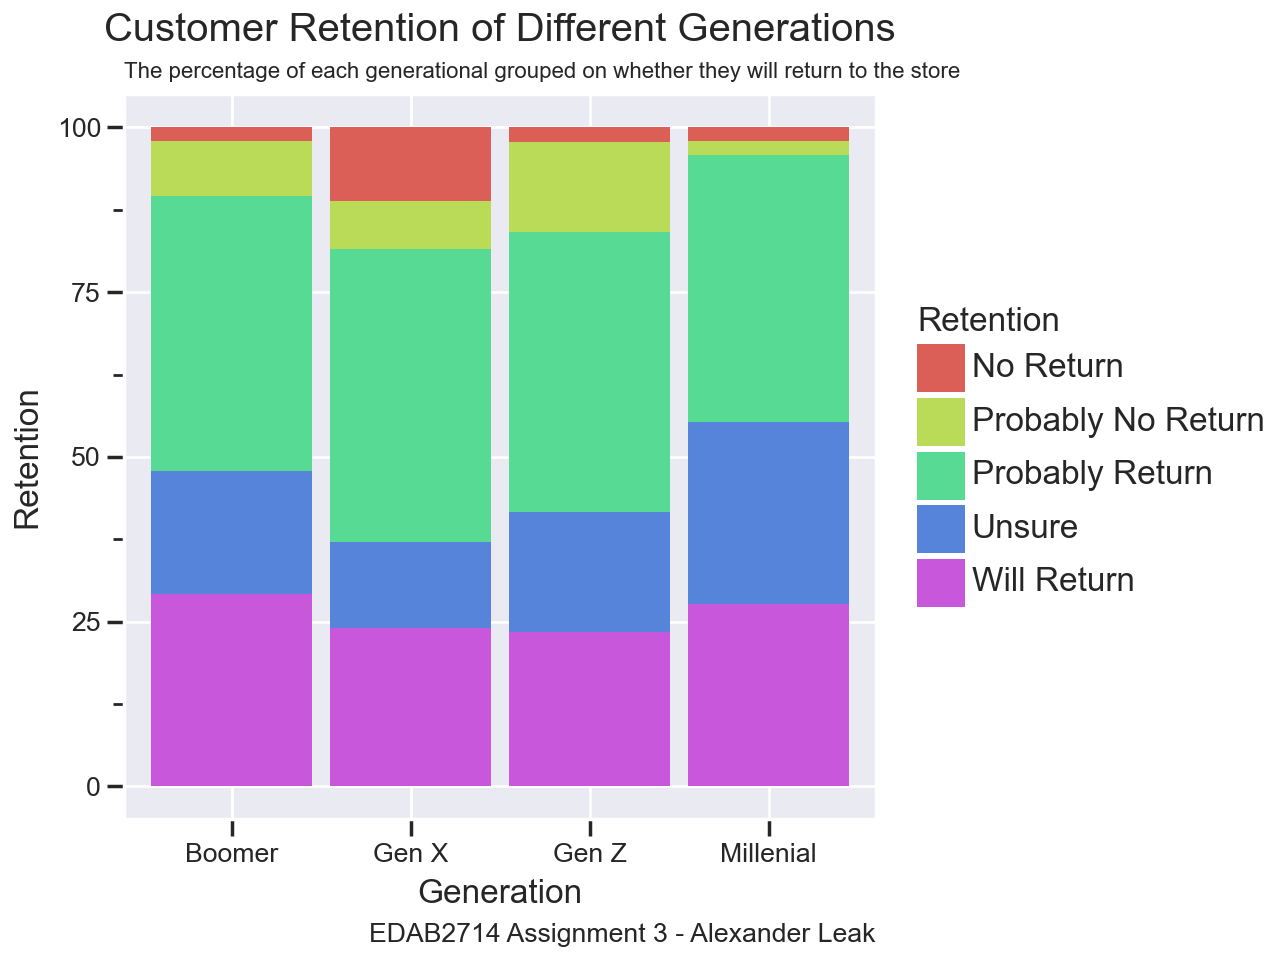

In [12]:
df_gen = df_reduced.groupby(by=['Generation','Retention']).size().reset_index(name='Count')

df_gen['%'] = 100*df_gen['Count'] / df_gen.groupby('Generation')['Count'].transform('sum')
df_gen

(
    p9.ggplot(df_gen, p9.aes(x='Generation',y='%',fill='Retention')) + 
    p9.geom_col() +
    p9.theme_seaborn() + 
    p9.labs(
        y = 'Retention',
        x = 'Generation',
        title = 'Customer Retention of Different Generations',
        subtitle = 'The percentage of each generational grouped on whether they will return to the store',
        caption = 'EDAB2714 Assignment 3 - Alexander Leak'
    )+
    p9.theme(
        plot_title= p9.element_text(ha='center',weight='light'),
        plot_subtitle=p9.element_text(size = 8,ha='left')
    )
)


In [13]:
df_gen

,Generation,Retention,Count,%
0,Boomer,No Return,1,2.083333
1,Boomer,Probably No Return,4,8.333333
2,Boomer,Probably Return,20,41.666667
3,Boomer,Unsure,9,18.750000
4,Boomer,Will Return,14,29.166667
5,Gen X,No Return,6,11.111111
6,Gen X,Probably No Return,4,7.407407
7,Gen X,Probably Return,24,44.444444
8,Gen X,Unsure,7,12.962963
9,Gen X,Will Return,13,24.074074


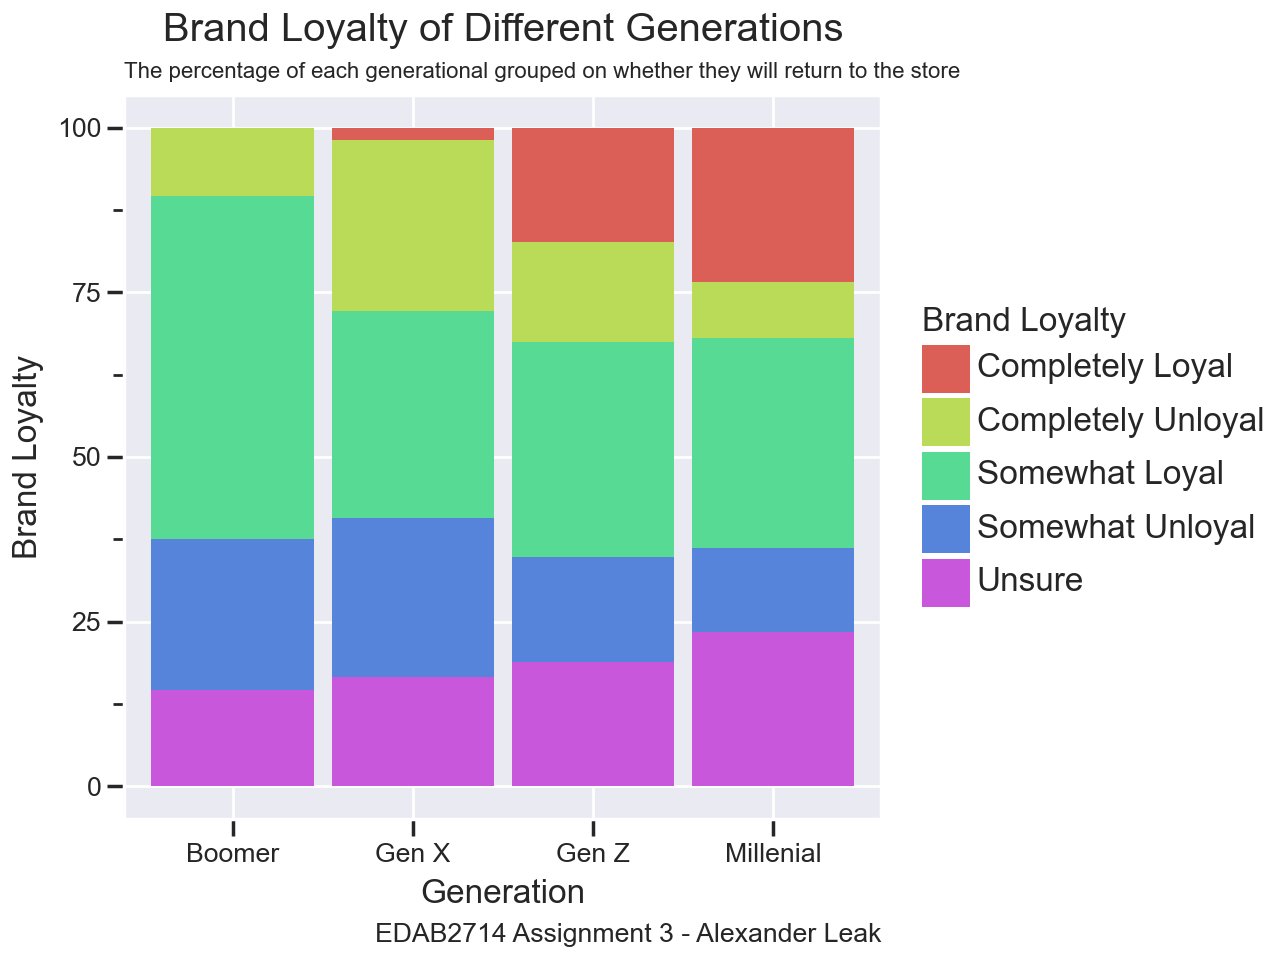

In [14]:
df_bl = df_reduced.groupby(by=['Generation','Brand Loyalty']).size().reset_index(name='Count')

df_bl['%'] = 100*df_bl['Count'] / df_bl.groupby('Generation')['Count'].transform('sum')

df_bl

(
    p9.ggplot(df_bl, p9.aes(x='Generation',y='%',fill='Brand Loyalty')) + 
    p9.geom_col() +
    p9.theme_seaborn() + 
    p9.labs(
        y = 'Brand Loyalty',
        x = 'Generation',
        title = 'Brand Loyalty of Different Generations',
        subtitle = 'The percentage of each generational grouped on whether they will return to the store',
        caption = 'EDAB2714 Assignment 3 - Alexander Leak'
    )+
    p9.theme(
        plot_title= p9.element_text(ha='center',weight='light'),
        plot_subtitle=p9.element_text(size = 8,ha='left')
    )
)

In [15]:
df_bl

,Generation,Brand Loyalty,Count,%
0,Boomer,Completely Unloyal,5,10.416667
1,Boomer,Somewhat Loyal,25,52.083333
2,Boomer,Somewhat Unloyal,11,22.916667
3,Boomer,Unsure,7,14.583333
4,Gen X,Completely Loyal,1,1.851852
5,Gen X,Completely Unloyal,14,25.925926
6,Gen X,Somewhat Loyal,17,31.481481
7,Gen X,Somewhat Unloyal,13,24.074074
8,Gen X,Unsure,9,16.666667
9,Gen Z,Completely Loyal,23,17.424242


#### Retention Trends

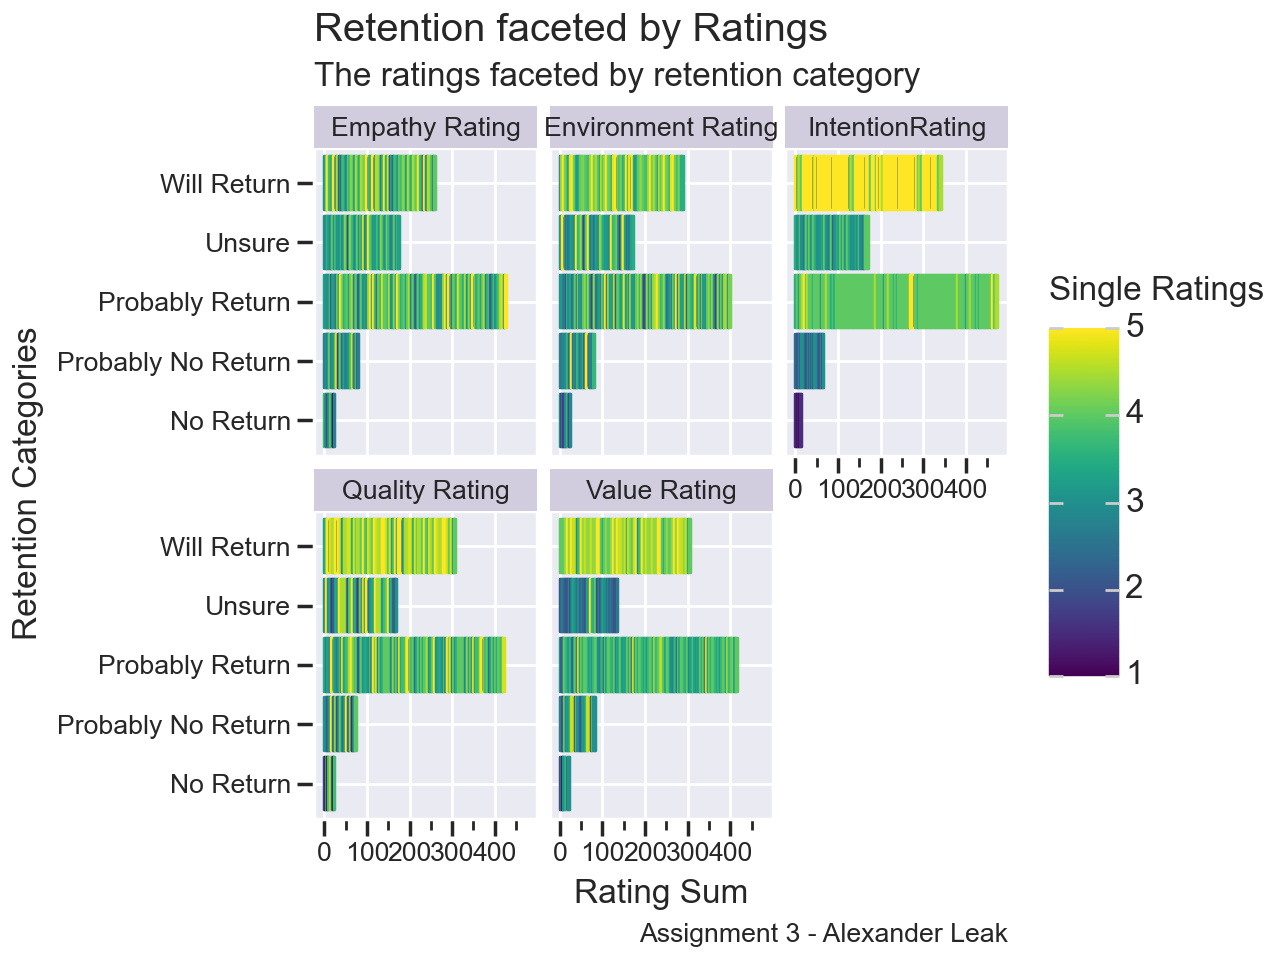

In [16]:
df_ret = pd.melt(df_reduced, id_vars='Retention',value_vars=['Empathy Rating','Value Rating','IntentionRating',
                                                             'Quality Rating','Environment Rating'])

(
    p9.ggplot(df_ret, p9.aes(x='Retention',y='value',color='value')) +
    p9.geom_col()+
    p9.facet_wrap('~variable') +
    p9.coord_flip()+
    p9.theme_seaborn()+
    p9.labs(
        x = 'Retention Categories',
        y = 'Rating Sum',
        title = 'Retention faceted by Ratings',
        subtitle = 'The ratings faceted by retention category',
        caption='Assignment 3 - Alexander Leak',
        color='Single Ratings'
    )
)

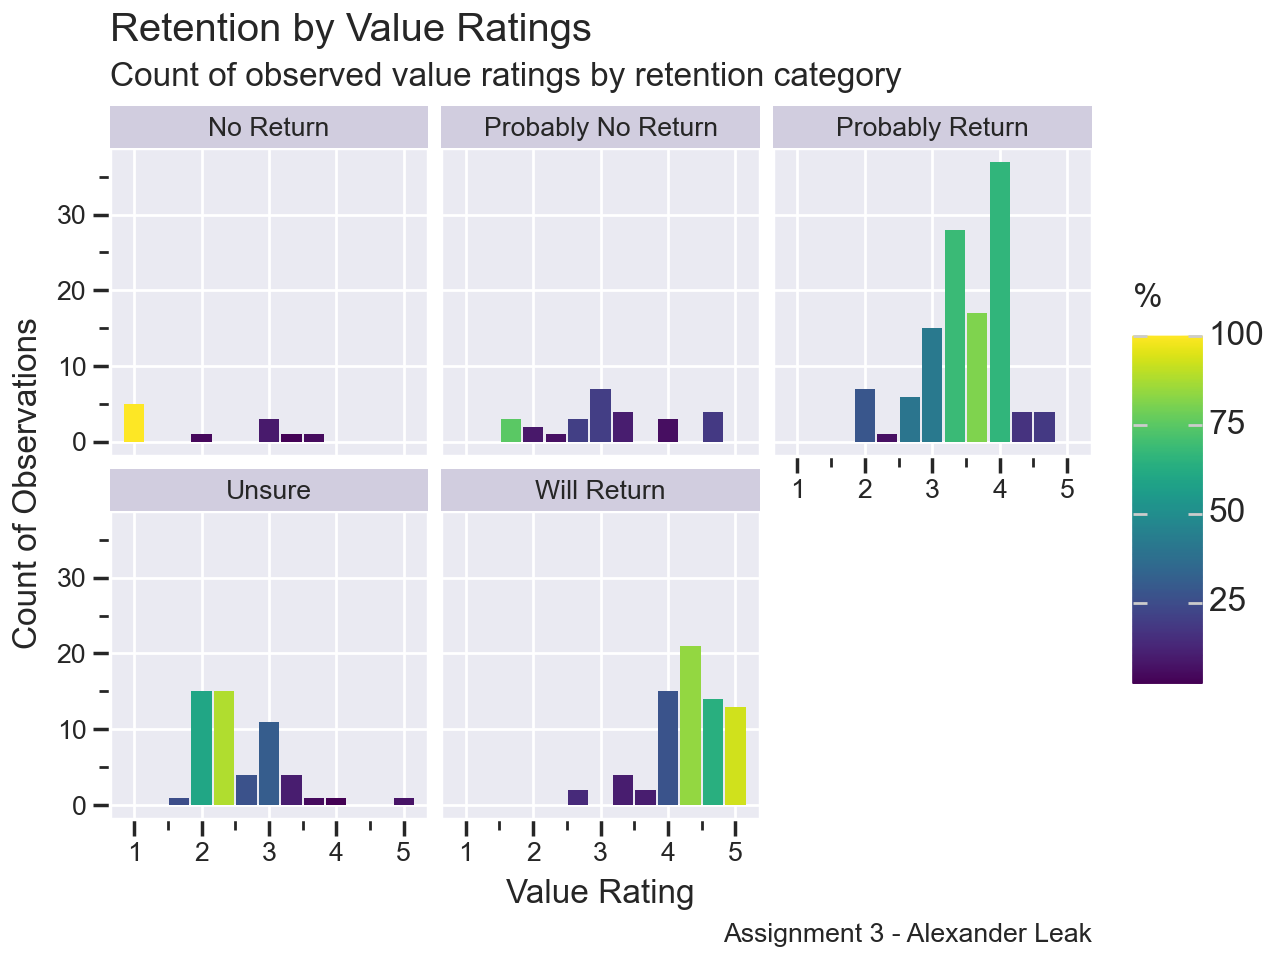

In [36]:
df_value = df_reduced.groupby(by=['Value Rating','Retention']).size().reset_index(name='count')

df_value['%'] = 100*df_value['count']/df_value.groupby('Value Rating')['count'].transform('sum')

df_value

(
    p9.ggplot(df_value,p9.aes(x='Value Rating',y='count',fill='%'))+
    p9.geom_col(stat='identity')+
    p9.facet_wrap('~Retention')+
    p9.labs(
        title='Retention by Value Ratings',
        subtitle='Count of observed value ratings by retention category',
        x = 'Value Rating',
        y = 'Count of Observations',
        caption = 'Assignment 3 - Alexander Leak'
    )+
    p9.theme(
        plot_title=p9.element_text(ha='center'),
        plot_subtitle=p9.element_text(ha='center')
    )+
    p9.theme_seaborn()
)

# Export to CSV

In [18]:
df_reduced.to_csv('Reduced.csv')